#📌 Extracción

In [3]:
import pandas as pd
import json

ruta_archivo = 'TelecomX_Data.json'
with open(ruta_archivo, 'r') as archivo:
    datos_crudos = json.load(archivo)

df = pd.json_normalize(datos_crudos)

print(f"La base de datos tiene {df.shape[0]} filas (clientes) y {df.shape[1]} columnas.\n")
display(df.head())

La base de datos tiene 7267 filas (clientes) y 21 columnas.



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [16]:
#Conociendo el conjunto de datos
print(f"El conjunto de datos tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print("--- Información de las columnas y tipos de datos ---")
df.info()

print("\n--- Muestra de los primeros 5 registros ---")
display(df.head())

El conjunto de datos tiene 7043 filas y 21 columnas.

--- Información de las columnas y tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [17]:
#Comprobación de incoherencias
print("Valores únicos en la columna Churn:")
print(df['Churn'].unique())

incoherencias_total = df[df['Charges.Total'] == ' ']
print(f"\nSe encontraron {len(incoherencias_total)} filas con espacios en blanco en 'Charges.Total'.")

Valores únicos en la columna Churn:
['No' 'Yes']

Se encontraron 0 filas con espacios en blanco en 'Charges.Total'.


In [18]:
#Manejo de inconsistencias
df = df[df['Churn'].isin(['Yes', 'No'])]
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

df['Charges.Total'] = df['Charges.Total'].fillna(0)

print("Tipos de datos actualizados tras la limpieza:")
print(df[['Churn', 'Charges.Total']].dtypes)

Tipos de datos actualizados tras la limpieza:
Churn             object
Charges.Total    float64
dtype: object


In [19]:
#Creación de la columna de cuentas diarias
df['Charges.Daily'] = (df['Charges.Monthly'] / 30).round(2)

print("\n--- Verificación de las nuevas columnas de cobro ---")
display(df[['Charges.Monthly', 'Charges.Daily', 'Charges.Total']].head())


--- Verificación de las nuevas columnas de cobro ---


,Charges.Monthly,Charges.Daily,Charges.Total
0,65.6,2.19,593.30
1,59.9,2.00,542.40
2,73.9,2.46,280.85
3,98.0,3.27,1237.85
4,83.9,2.80,267.40


#📊 Carga y análisis

In [20]:
#Análisis Descriptivo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("--- ANÁLISIS DESCRIPTIVO: VARIABLES NUMÉRICAS ---")
display(df.describe().round(2))

print("\n--- ANÁLISIS DESCRIPTIVO: VARIABLES CATEGÓRICAS (Texto) ---")
display(df.describe(include=['object']))

--- ANÁLISIS DESCRIPTIVO: VARIABLES NUMÉRICAS ---


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Charges.Daily
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73,2.16
std,0.37,24.56,30.09,2266.79,1.00
min,0.00,0.00,18.25,0.00,0.61
25%,0.00,9.00,35.50,398.55,1.18
50%,0.00,29.00,70.35,1394.55,2.34
75%,0.00,55.00,89.85,3786.60,2.99
max,1.00,72.00,118.75,8684.80,3.96



--- ANÁLISIS DESCRIPTIVO: VARIABLES CATEGÓRICAS (Texto) ---


,customerID,Churn,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5174,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


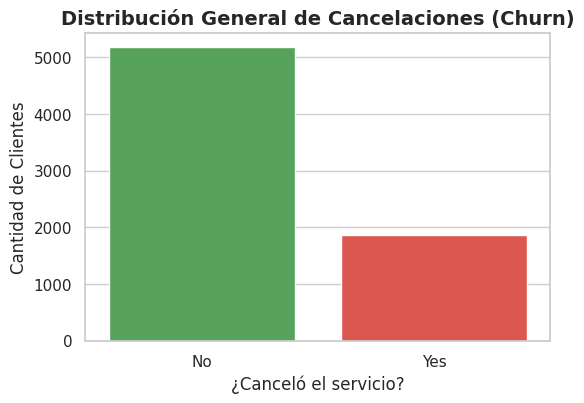

In [21]:
#Distribución de evasión
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn', hue='Churn', palette=['#4CAF50', '#F44336'], legend=False)

plt.title('Distribución General de Cancelaciones (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('¿Canceló el servicio?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

plt.show()

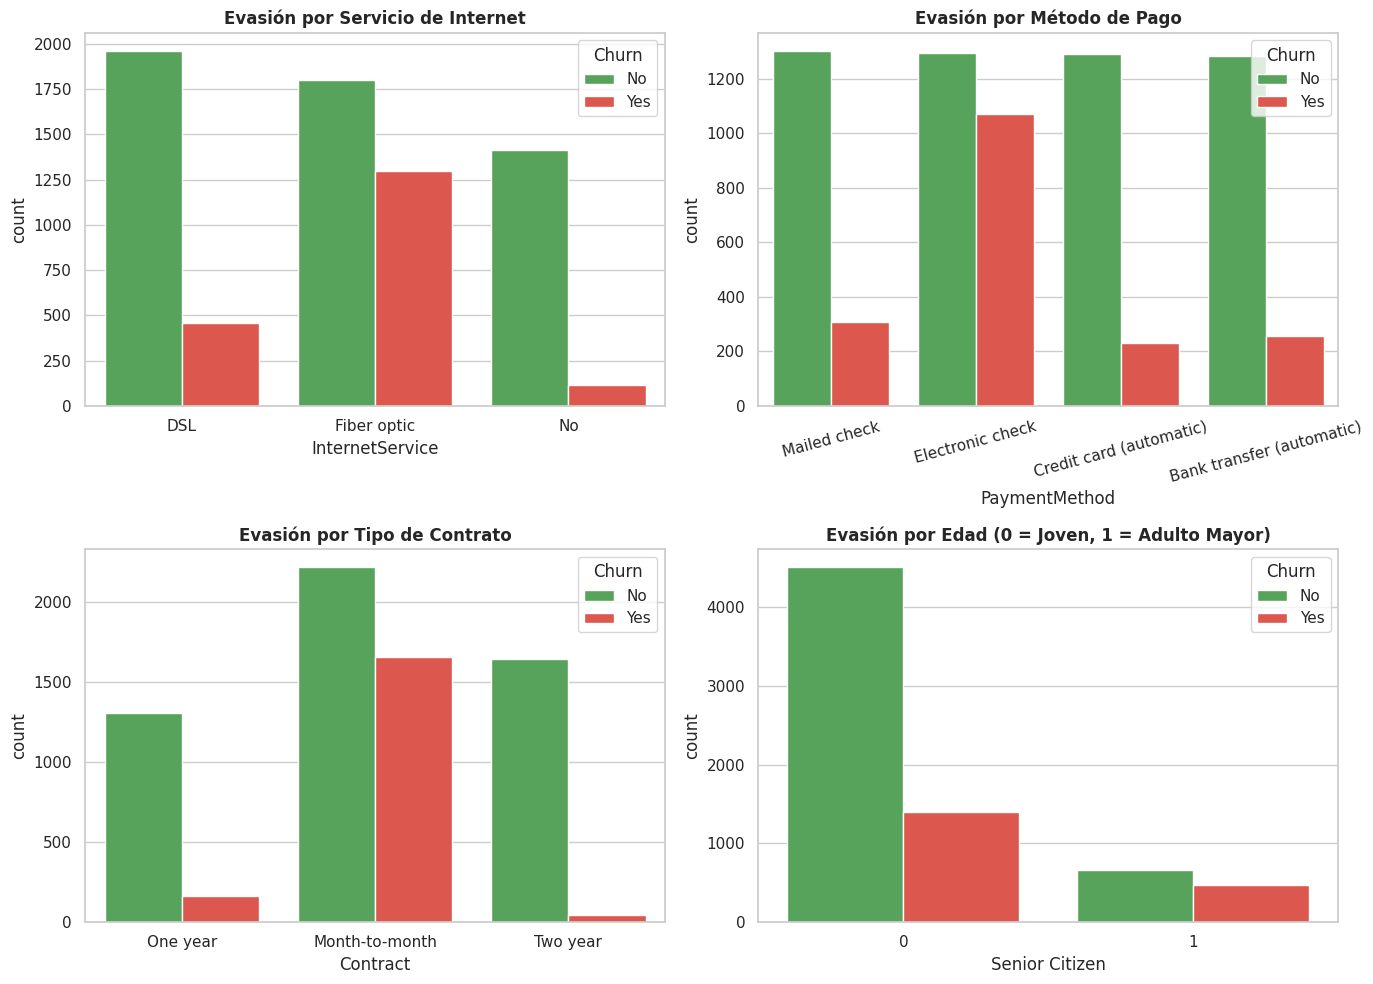

In [22]:
#Recuento de evasión por variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0,0], palette=['#4CAF50', '#F44336'])
axes[0,0].set_title('Evasión por Servicio de Internet', fontweight='bold')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0,1], palette=['#4CAF50', '#F44336'])
axes[0,1].set_title('Evasión por Método de Pago', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15) # Rotamos los textos para que se lean bien

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1,0], palette=['#4CAF50', '#F44336'])
axes[1,0].set_title('Evasión por Tipo de Contrato', fontweight='bold')
sns.countplot(data=df, x=df['SeniorCitizen'].astype(str), hue='Churn', ax=axes[1,1], palette=['#4CAF50', '#F44336'])
axes[1,1].set_title('Evasión por Edad (0 = Joven, 1 = Adulto Mayor)', fontweight='bold')
axes[1,1].set_xlabel('Senior Citizen')

plt.tight_layout()
plt.show()

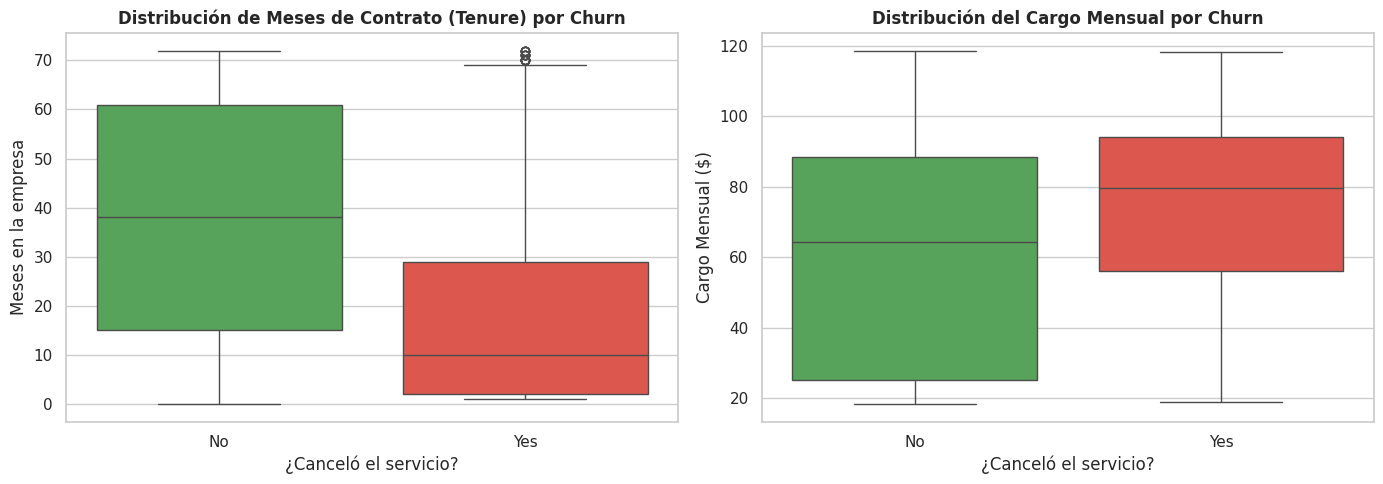

In [23]:
#Conteo de evasión por variables numéricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', ax=axes[0], palette=['#4CAF50', '#F44336'], legend=False)
axes[0].set_title('Distribución de Meses de Contrato (Tenure) por Churn', fontweight='bold')
axes[0].set_ylabel('Meses en la empresa')
axes[0].set_xlabel('¿Canceló el servicio?')

sns.boxplot(data=df, x='Churn', y='Charges.Monthly', hue='Churn', ax=axes[1], palette=['#4CAF50', '#F44336'], legend=False)
axes[1].set_title('Distribución del Cargo Mensual por Churn', fontweight='bold')
axes[1].set_ylabel('Cargo Mensual ($)')
axes[1].set_xlabel('¿Canceló el servicio?')

plt.tight_layout()
plt.show()

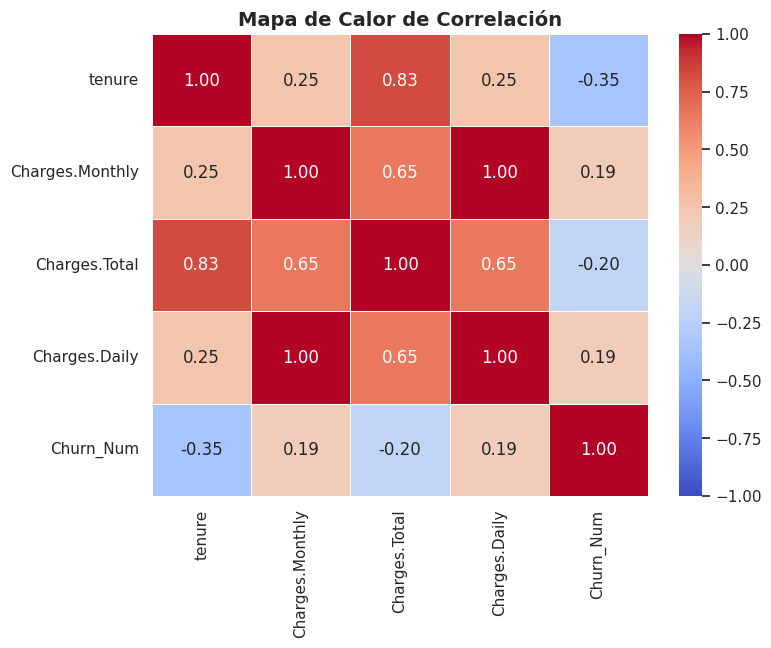

In [24]:
#Análisis de Correlación entre variables
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Charges.Daily', 'Churn_Num']
matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación', fontsize=14, fontweight='bold')
plt.show()

#📄Informe final

Tras realizar la limpieza y exploración de los datos, se identifica los principales factores de riesgo que conducen a la cancelación del servicio:

    El perfil de mayor riesgo (Variables Categóricas):

        Contrato: La inmensa mayoría de las deserciones ocurren en clientes con contratos mes a mes (Month-to-month). Los contratos a 1 o 2 años brindan una gran retención.

        Servicio de Internet: Los usuarios con Fibra Óptica tienen una tasa de cancelación alarmantemente más alta que los de DSL. Esto sugiere un problema de calidad técnica o de precio en este servicio específico.

        Método de Pago: El pago mediante Cheque Electrónico (Electronic check) está fuertemente vinculado a las cancelaciones.

    El impacto del tiempo y el dinero (Variables Numéricas):

        Antigüedad (Tenure): El gráfico de cajas muestra que quienes cancelan el servicio lo hacen mayormente en sus primeros meses (la caja roja está muy abajo, promediando menos de 15 meses). El periodo inicial es crítico para retener al cliente.

        Costo Mensual: Quienes cancelan (Churn = Yes) tienden a tener facturas mensuales significativamente más altas (caja roja desplazada hacia arriba) que quienes se quedan.